## Cross-correlation coefficient of the NPE posterior-mean convergence with the true convergence

Plot $r(\theta) = \xi_{tp}(\theta) / \sqrt{\xi_{tt}(\theta)\, \xi_{pp}(\theta)}$ for each redshift bin, where $\xi_{tt}$, $\xi_{pp}$, and $\xi_{tp}$ are the convergence auto- and cross-correlations of the true map and the NPE posterior-mean map. This is the real-space analog of Figure 6 of Boruah, Rozo & Fiedorowicz (2022).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import treecorr
from einops import rearrange
from hydra import compose, initialize
from hydra.utils import instantiate

plt.rcParams["font.family"] = "serif"

import lightning as L
from lightning.pytorch.utilities import move_data_to_device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/home/twhit/blissWL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


**Load the NPE checkpoint:**

In [2]:
ckpt = "/data/scratch/twhit/checkpoints/trained_encoder_dc2.ckpt"

with initialize(config_path="../", version_base=None):
    cfg = compose(
        "config_train_npe",
        {
            "train.pretrained_weights=" + ckpt,
        },
    )

seed = L.seed_everything(cfg.train.seed)

Seed set to 123123


**Configure the test dataloader:**

In [3]:
data_source = instantiate(cfg.train.data_source)
data_source.setup("test")
test_dl = data_source.test_dataloader()

**Load encoder weights:**

In [4]:
encoder = instantiate(cfg.encoder).to(device)
encoder_state_dict = torch.load(cfg.train.pretrained_weights, map_location=device)["state_dict"]
encoder.load_state_dict(encoder_state_dict, strict=False)
encoder = encoder.eval()

/home/twhit/blissWL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


**Run inference on the test set to collect the true convergence, the posterior-mean convergence, and tile positions:**

In [5]:
torch.manual_seed(0)

num_tiles_per_side = 8
num_bins = 4

convergence_true = torch.zeros(
    len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device
)
convergence_pred = torch.zeros(
    len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device
)
ra = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
dec = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)

i = -1
for b in test_dl:
    i += 1
    print(i)
    batch = move_data_to_device(b, device)

    convergence_true[i] = batch["tile_catalog"]["convergence"].squeeze()
    ra[i] = batch["tile_catalog"]["ra"].squeeze()
    dec[i] = batch["tile_catalog"]["dec"].squeeze()

    with torch.no_grad():
        input_lst = [inorm.get_input_tensor(batch) for inorm in encoder.image_normalizers]
        inputs = torch.cat(input_lst, dim=2)

        x_cat_marginal = encoder.net(inputs).squeeze(0)
        convergence_pred[i] = x_cat_marginal[:, :, (4 * num_bins) : (5 * num_bins)].squeeze()

0


1
2


3


4


5


...

35


36


37


38


39


**Compute the cross-correlation coefficient $r(\theta)$ per redshift bin using `treecorr`:**

For each bin we compute three $\kappa\kappa$ correlation functions across all tiles in the test set:
- $\xi_{tt}(\theta)$: true auto-correlation
- $\xi_{pp}(\theta)$: posterior-mean auto-correlation  
- $\xi_{tp}(\theta)$: cross-correlation between true and posterior-mean

Then $r(\theta) = \xi_{tp}/\sqrt{\xi_{tt}\,\xi_{pp}}$. Tiles from the 40 non-contiguous test images are all placed into a single `treecorr` catalog; pairs across distant images fall outside `max_sep` and do not contribute.

In [6]:
min_sep = 1.0
max_sep = 30.0
nbins = 15
sep_units = "arcmin"

ra_np = ra[..., 0].flatten().cpu().numpy()
dec_np = dec[..., 0].flatten().cpu().numpy()

r_per_bin = []
theta_per_bin = []

for b in range(num_bins):
    k_true = convergence_true[..., b].flatten().cpu().numpy().astype(np.float64)
    k_pred = convergence_pred[..., b].flatten().cpu().numpy().astype(np.float64)

    cat_true = treecorr.Catalog(
        ra=ra_np, dec=dec_np, ra_units="deg", dec_units="deg", k=k_true
    )
    cat_pred = treecorr.Catalog(
        ra=ra_np, dec=dec_np, ra_units="deg", dec_units="deg", k=k_pred
    )

    kk_tt = treecorr.KKCorrelation(
        min_sep=min_sep, max_sep=max_sep, nbins=nbins, sep_units=sep_units
    )
    kk_pp = treecorr.KKCorrelation(
        min_sep=min_sep, max_sep=max_sep, nbins=nbins, sep_units=sep_units
    )
    kk_tp = treecorr.KKCorrelation(
        min_sep=min_sep, max_sep=max_sep, nbins=nbins, sep_units=sep_units
    )

    kk_tt.process(cat_true)
    kk_pp.process(cat_pred)
    kk_tp.process(cat_true, cat_pred)

    theta = np.exp(kk_tt.meanlogr)
    r_theta = kk_tp.xi / np.sqrt(kk_tt.xi * kk_pp.xi)

    theta_per_bin.append(theta)
    r_per_bin.append(r_theta)

    print(
        f"bin {b + 1}: r(θ) range = [{np.nanmin(r_theta):.3f}, {np.nanmax(r_theta):.3f}]"
    )

# Cauchy–Schwarz bounds r in [-1, 1] for infinite-sample correlations; the finite-sample
# treecorr estimator can overshoot at scales where the auto-correlations are small.
max_abs_r = max(
    float(np.nanmax(np.abs(rt[np.isfinite(rt)]))) for rt in r_per_bin
)
print(f"max |r(θ)| across all bins = {max_abs_r:.3f}")

bin 1: r(θ) range = [0.751, 1.341]
bin 2: r(θ) range = [0.827, 1.107]
bin 3: r(θ) range = [0.867, 1.048]


bin 4: r(θ) range = [0.836, 1.052]
max |r(θ)| across all bins = 1.341


**Plot $r(\theta)$, one curve per redshift bin:**

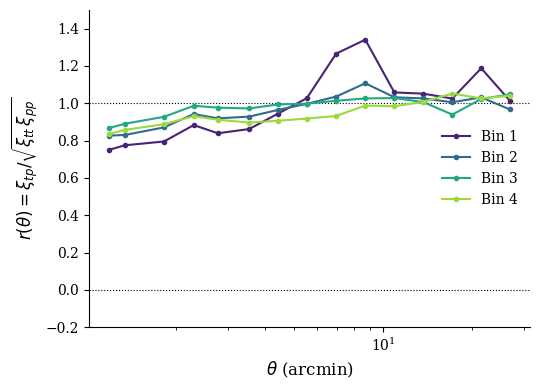

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4))

colors = plt.cm.viridis(np.linspace(0.1, 0.85, num_bins))

for b in range(num_bins):
    ax.plot(
        theta_per_bin[b],
        r_per_bin[b],
        color=colors[b],
        marker="o",
        markersize=3,
        label=f"Bin {b + 1}",
    )

ax.axhline(1.0, color="black", linestyle=":", linewidth=0.8, zorder=0)
ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8, zorder=0)

ax.set_xscale("log")
ax.set_xlabel(r"$\theta$ (arcmin)", fontsize=12)
ax.set_ylabel(r"$r(\theta) = \xi_{tp} / \sqrt{\xi_{tt}\, \xi_{pp}}$", fontsize=12)
ax.set_ylim(-0.2, 1.5)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

fig.savefig(
    "figures/crosscorrelation.png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

**Harmonic-space version — $r(\ell)$ on the stitched test-set map:**

Sort the 40 test images spatially by RA/Dec (as in `posteriormeanmaps.ipynb`) to form a single contiguous tile grid of shape $8 \times 8$ images laid out in a $8 \times 5$ (dec, ra) arrangement — giving a $64 \times 40$ tile map covering roughly $0.91° \times 0.57°$ at $0.853$ arcmin per tile. Per redshift bin, take a 2D FFT of this stitched map for both the true and the posterior-mean convergence, radially bin $|\ell|$ in log-spaced shells, and compute $r(\ell) = C_{tp}(\ell) / \sqrt{C_{tt}(\ell)\,C_{pp}(\ell)}$. This reaches lower $\ell$ than the per-image version: $\ell_\text{fund} \approx 2\pi/L \approx 400$, $\ell_\text{Nyq} \approx \pi/\Delta \approx 12700$.

In [8]:
num_dec_images = 8
num_ra_images = 5

# sort images by dec (rows) then by -ra within each row, mirroring posteriormeanmaps.ipynb
ra_mean = ra[..., 0].mean([1, 2])
dec_mean = dec[..., 0].mean([1, 2])
dec_bins = torch.argsort(dec_mean).view(num_dec_images, num_ra_images)
sorted_indices = torch.zeros_like(dec_bins)
for i in range(num_dec_images):
    ra_in_row = ra_mean[dec_bins[i]]
    sorted_indices[i] = dec_bins[i][torch.argsort(-ra_in_row)]
idx = sorted_indices.flatten()

# stitched map: (64, 40, num_bins)
convergence_true_stitched = rearrange(
    convergence_true[idx].view(
        num_dec_images, num_ra_images, num_tiles_per_side, num_tiles_per_side, num_bins
    ),
    "h w nh nw b -> (h nh) (w nw) b",
).cpu().numpy().astype(np.float64)
convergence_pred_stitched = rearrange(
    convergence_pred[idx].view(
        num_dec_images, num_ra_images, num_tiles_per_side, num_tiles_per_side, num_bins
    ),
    "h w nh nw b -> (h nh) (w nw) b",
).cpu().numpy().astype(np.float64)

ny, nx = convergence_true_stitched.shape[:2]
print(f"stitched map shape: ({ny}, {nx}) tiles")

tile_slen_arcmin = 0.853
tile_slen_rad = tile_slen_arcmin * np.pi / (180.0 * 60.0)

kx = np.fft.fftfreq(nx, d=tile_slen_rad) * 2 * np.pi
ky = np.fft.fftfreq(ny, d=tile_slen_rad) * 2 * np.pi
ellx, elly = np.meshgrid(kx, ky)  # shape (ny, nx)
ell_mag = np.sqrt(ellx**2 + elly**2)

ell_fundamental = 2 * np.pi / (max(ny, nx) * tile_slen_rad)
ell_nyquist = np.pi / tile_slen_rad

# Log-spaced ℓ bins (matching Boruah et al. Fig 6 convention),
# filtered to those with enough modes for a stable ratio.
ell_edges = np.logspace(np.log10(ell_fundamental * 0.9), np.log10(ell_nyquist), 14)
min_modes_per_bin = 10
mode_counts = np.array(
    [
        int(((ell_mag >= ell_edges[i]) & (ell_mag < ell_edges[i + 1])).sum())
        for i in range(len(ell_edges) - 1)
    ]
)
keep_mask = mode_counts >= min_modes_per_bin
print(f"modes per bin (all): {mode_counts}")
print(f"kept {keep_mask.sum()} / {len(keep_mask)} bins (min {min_modes_per_bin} modes)")

ell_centers_all = np.sqrt(ell_edges[:-1] * ell_edges[1:])
ell_centers = ell_centers_all[keep_mask]

r_ell_per_bin = []
for b in range(num_bins):
    fft_t = np.fft.fft2(convergence_true_stitched[..., b])
    fft_p = np.fft.fft2(convergence_pred_stitched[..., b])

    P_tt_2d = np.abs(fft_t) ** 2
    P_pp_2d = np.abs(fft_p) ** 2
    P_tp_2d = np.real(np.conj(fft_t) * fft_p)

    C_tt_all = np.zeros(len(ell_centers_all))
    C_pp_all = np.zeros(len(ell_centers_all))
    C_tp_all = np.zeros(len(ell_centers_all))
    for i in range(len(ell_centers_all)):
        mask = (ell_mag >= ell_edges[i]) & (ell_mag < ell_edges[i + 1])
        if mask.any():
            C_tt_all[i] = P_tt_2d[mask].mean()
            C_pp_all[i] = P_pp_2d[mask].mean()
            C_tp_all[i] = P_tp_2d[mask].mean()

    r_ell = (C_tp_all / np.sqrt(C_tt_all * C_pp_all))[keep_mask]
    r_ell_per_bin.append(r_ell)

print(f"ℓ bin centers: {np.array2string(ell_centers, precision=0)}")

stitched map shape: (64, 40) tiles
modes per bin (all): [  2   0   8   4  12  14  30  56  98 160 286 488 830]
kept 9 / 13 bins (min 10 modes)
ℓ bin centers: [ 1226.  1613.  2123.  2795.  3678.  4841.  6371.  8385. 11036.]


/tmp/ipykernel_4084649/1803460663.py:78: RuntimeWarning: invalid value encountered in divide
  r_ell = (C_tp_all / np.sqrt(C_tt_all * C_pp_all))[keep_mask]


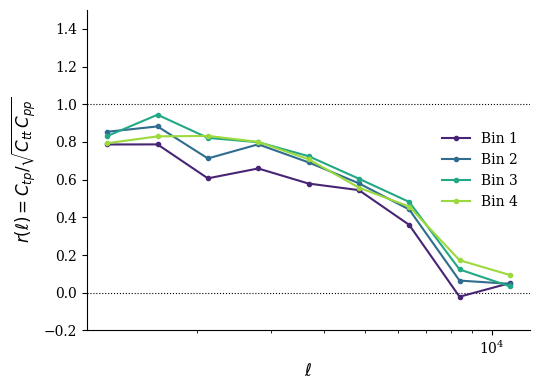

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4))

for b in range(num_bins):
    ax.plot(
        ell_centers,
        r_ell_per_bin[b],
        color=colors[b],
        marker="o",
        markersize=3,
        label=f"Bin {b + 1}",
    )

ax.axhline(1.0, color="black", linestyle=":", linewidth=0.8, zorder=0)
ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8, zorder=0)

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$", fontsize=12)
ax.set_ylabel(r"$r(\ell) = C_{tp} / \sqrt{C_{tt}\, C_{pp}}$", fontsize=12)
ax.set_ylim(-0.2, 1.5)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

fig.savefig(
    "figures/crosscorrelation_ell.png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)